# PRCP-1016: Heart Disease Prediction Using Machine Learning  

## Problem Statement
Cardiovascular diseases (CVDs) are the leading cause of death globally, accounting for an estimated 17.9 million lives each year. Heart failure and cardiac events often occur due to underlying cardiovascular risk factors like hypertension, hyperlipidemia, or vascular abnormalities. Early detection through predictive machine learning models enables proactive medical intervention, reducing life-threatening events. The primary goal of this project is to analyze patient clinical data, construct predictive models to forecast heart disease presence, and provide actionable operational recommendations for hospital management.  

# Tasks

# Task 1: Data Analysis Report

## 1. Overview & Dataset Structure
* **Dataset Size:** The dataset contains 180 patient records across 15 columns.
* **Column Types:** Includes 1 unique identifier (`patient_id`), 8 categorical attributes, and 5 continuous numerical variables.
* **Target Variable:** `heart_disease_present` is a balanced binary target (100 negative cases at 55.6% vs. 80 positive cases at 44.4%).
* **Data Quality:** 0 missing values, 0 duplicate records, and no conflicting data types detected.

---

### Task 2: Predictive Model Development & Comparison
Develop and evaluate machine learning models to identify potential heart disease risk by:
* Encoding categorical attributes and scaling continuous features without data leakage.
* Splitting data into stratified training and testing sets to preserve class distribution.
* Training multiple classifiers (Logistic Regression, Decision Tree, Random Forest, KNN, SVM).
* Evaluating model performance using Accuracy, Precision, Recall, and F1-Score metrics.
* Performing feature importance analysis and confusion matrix evaluation on the champion model.
* Designing a real-time single-patient inference pipeline with probability outputs.
----


### Task 3: Suggestions to the Hospital
Provide strategic recommendations to hospital administration to prevent life-threatening cardiac events by:
* Designing early-warning triage and patient risk stratification workflows.
* Prioritizing high-impact diagnostic tests based on model feature rankings.
* Establishing threshold alerting protocols for critical multi-factor risk profiles.

## Dataset Features

1. **`patient_id`** – Unique random identifier for each patient record.
2. **`age`** – Age of the patient in years.
3. **`sex`** – Biological sex of the patient (0: Female, 1: Male).
4. **`chest_pain_type`** – Type of chest pain experienced (4 categorical values).
5. **`resting_blood_pressure`** – Resting blood pressure reading in mm Hg.
6. **`serum_cholesterol_mg_per_dl`** – Serum cholesterol measurement in mg/dl.
7. **`fasting_blood_sugar_gt_120_mg_per_dl`** – Fasting blood sugar level > 120 mg/dl (1: True, 0: False).
8. **`resting_ekg_results`** – Resting electrocardiographic results (0, 1, 2).
9. **`max_heart_rate_achieved`** – Maximum heart rate achieved during exercise stress testing.
10. **`exercise_induced_angina`** – Exercise-induced angina/chest pain (1: True, 0: False).
11. **`oldpeak_eq_st_depression`** – ST depression induced by exercise relative to rest.
12. **`slope_of_peak_exercise_st_segment`** – Slope of the peak exercise ST segment (1, 2, 3).
13. **`num_major_vessels`** – Number of major blood vessels (0–3) colored by fluoroscopy.
14. **`thal`** – Thallium stress test result (normal, fixed_defect, reversible_defect).

---



## Target Variable

**`heart_disease_present`** – Binary target variable indicating the diagnostic presence of heart disease (0: Disease Absent, 1: Disease Present).

-------

## Project Workflow

1. Import Required Libraries & Dependencies
2. Load Dataset & Perform Initial Inspection.
3. Verify Data Schema, Types & Missing Values.
4. Perform Data Cleaning & Identifier Cleanup (`patient_id`).
5. Conduct Exploratory Data Analysis (EDA) & Data Visualization
6. Execute Statistical Hypothesis Testing (T-Tests & Chi-Square Tests).
7. Apply Categorical Encoding (One-Hot Encoding for `thal`) .
8. Perform Stratified Train-Test Data Splitting.
9. Apply Feature Standardization using `StandardScaler`
10. Train Multiple Predictive Models (Logistic Regression, Decision Tree, Random Forest, KNN, SVM).
11. Evaluate Model Performance Metrics (Accuracy, Precision, Recall, F1-Score).
12. Compare Predictive Performance across Models.
13. Select Champion Production Model (Random Forest Classifier).
14. Generate & Interpret Confusion Matrix
15. Extract & Visualize Random Forest Feature Importances.
16. Compare Actual vs. Predicted Diagnostic Labels
17. Build Reusable Single-Patient Inference Pipeline (`predict_heart_disease`).
18. Validate Model Predictions on Low-Risk and High-Risk Clinical Profiles.
19. Compile Hospital Operational Recommendations.
20. Document Technical Challenges Faced & Solutions Implemented.
21. Final Conclusion & Deployment Readiness.

### Data Import, Environment Setup & Dataset Merging

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
folder = r'C:\Users\srinithi\Downloads\PRCP-1016-HeartDieseasePred\Data'
values = pd.read_csv(folder + r'\values.csv')
labels = pd.read_csv(folder + r'\labels.csv')
df = values.merge(labels, on='patient_id', how='inner')
print(df.shape)
df.head()

(180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


### Structural Data Inspection

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

### Summary Statistics

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,180,180,0z64un,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slope_of_peak_exercise_st_segment,180.0,NaN,NaN,NaN,1.55,0.618838,1.0,1.0,1.0,2.0,3.0
thal,180,3,normal,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resting_blood_pressure,180.0,NaN,NaN,NaN,131.311111,17.010443,94.0,120.0,130.0,140.0,180.0
chest_pain_type,180.0,NaN,NaN,NaN,3.155556,0.938454,1.0,3.0,3.0,4.0,4.0
num_major_vessels,180.0,NaN,NaN,NaN,0.694444,0.969347,0.0,0.0,0.0,1.0,3.0
fasting_blood_sugar_gt_120_mg_per_dl,180.0,NaN,NaN,NaN,0.161111,0.368659,0.0,0.0,0.0,0.0,1.0
resting_ekg_results,180.0,NaN,NaN,NaN,1.05,0.998742,0.0,0.0,2.0,2.0,2.0
serum_cholesterol_mg_per_dl,180.0,NaN,NaN,NaN,249.211111,52.717969,126.0,213.75,245.5,281.25,564.0
oldpeak_eq_st_depression,180.0,NaN,NaN,NaN,1.01,1.121357,0.0,0.0,0.8,1.6,6.2


### Data Integrity & Quality Check

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate patient_ids:", df['patient_id'].duplicated().sum())

Missing values per column:
patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

Duplicate rows: 0
Duplicate patient_ids: 0


### Feature Categorization & Variable Definition

In [5]:
categorical_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar_gt_120_mg_per_dl',
                     'resting_ekg_results', 'exercise_induced_angina', 'slope_of_peak_exercise_st_segment',
                     'thal', 'num_major_vessels']

numeric_cols = ['age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl',
                 'max_heart_rate_achieved', 'oldpeak_eq_st_depression']

target_col = 'heart_disease_present'

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['sex', 'chest_pain_type', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'exercise_induced_angina', 'slope_of_peak_exercise_st_segment', 'thal', 'num_major_vessels']
Numeric: ['age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl', 'max_heart_rate_achieved', 'oldpeak_eq_st_depression']


### Target Variable Distribution & Class Balance

heart_disease_present
0    100
1     80
Name: count, dtype: int64
heart_disease_present
0    55.555556
1    44.444444
Name: proportion, dtype: float64


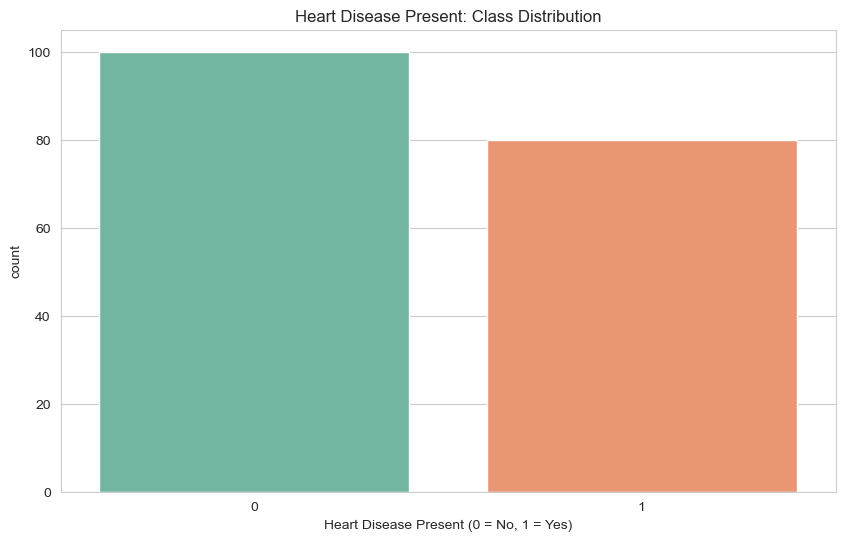

In [6]:
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True) * 100)

sns.countplot(x=target_col, data=df, hue=target_col, palette='Set2', legend=False)
plt.title('Heart Disease Present: Class Distribution')
plt.xlabel('Heart Disease Present (0 = No, 1 = Yes)')
plt.show()

### Numerical Feature Distributions

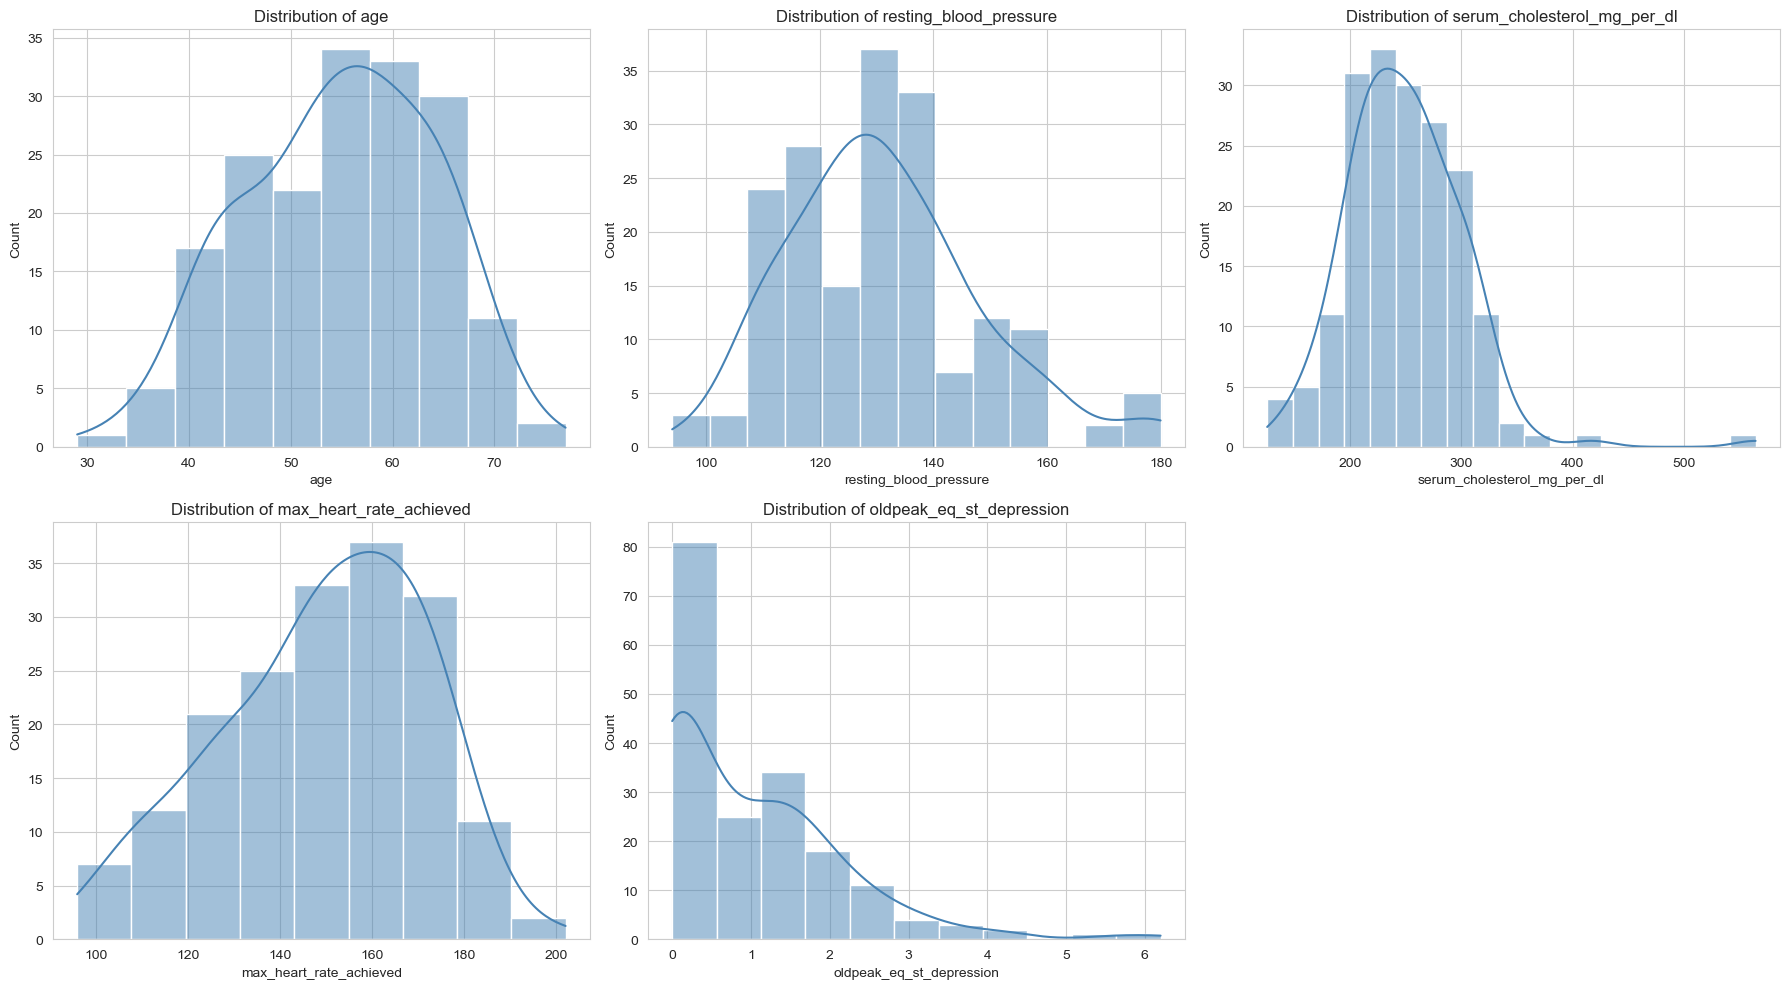

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


### Summary Statistics & Outlier Analysis

In [8]:
summary = df[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew']).T
summary

,mean,median,std,min,max,skew
age,54.811111,55.0,9.334737,29.0,77.0,-0.199166
resting_blood_pressure,131.311111,130.0,17.010443,94.0,180.0,0.657080
serum_cholesterol_mg_per_dl,249.211111,245.5,52.717969,126.0,564.0,1.273932
max_heart_rate_achieved,149.483333,152.0,22.063513,96.0,202.0,-0.393705
oldpeak_eq_st_depression,1.010000,0.8,1.121357,0.0,6.2,1.507412


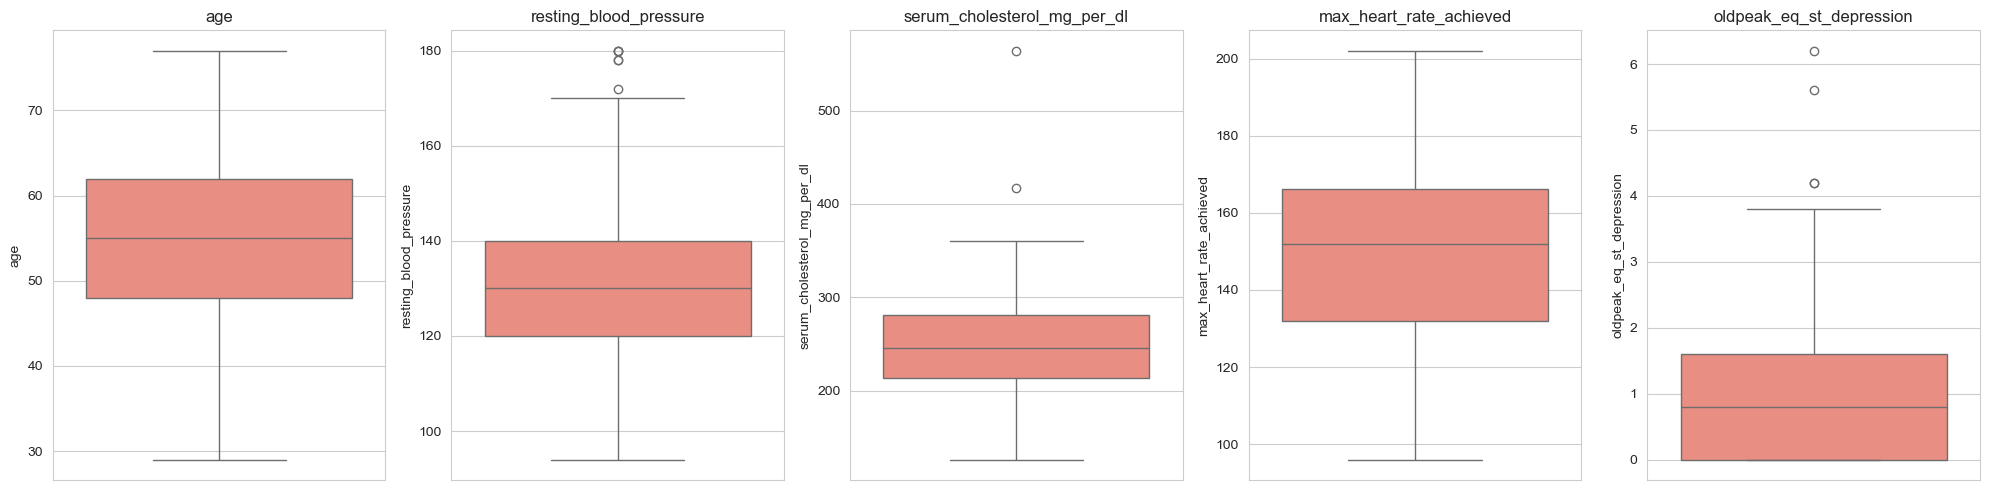

age: 0 outliers
resting_blood_pressure: 6 outliers
serum_cholesterol_mg_per_dl: 2 outliers
max_heart_rate_achieved: 0 outliers
oldpeak_eq_st_depression: 4 outliers


In [9]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_out} outliers")

### Categorical Feature Frequency Distributions

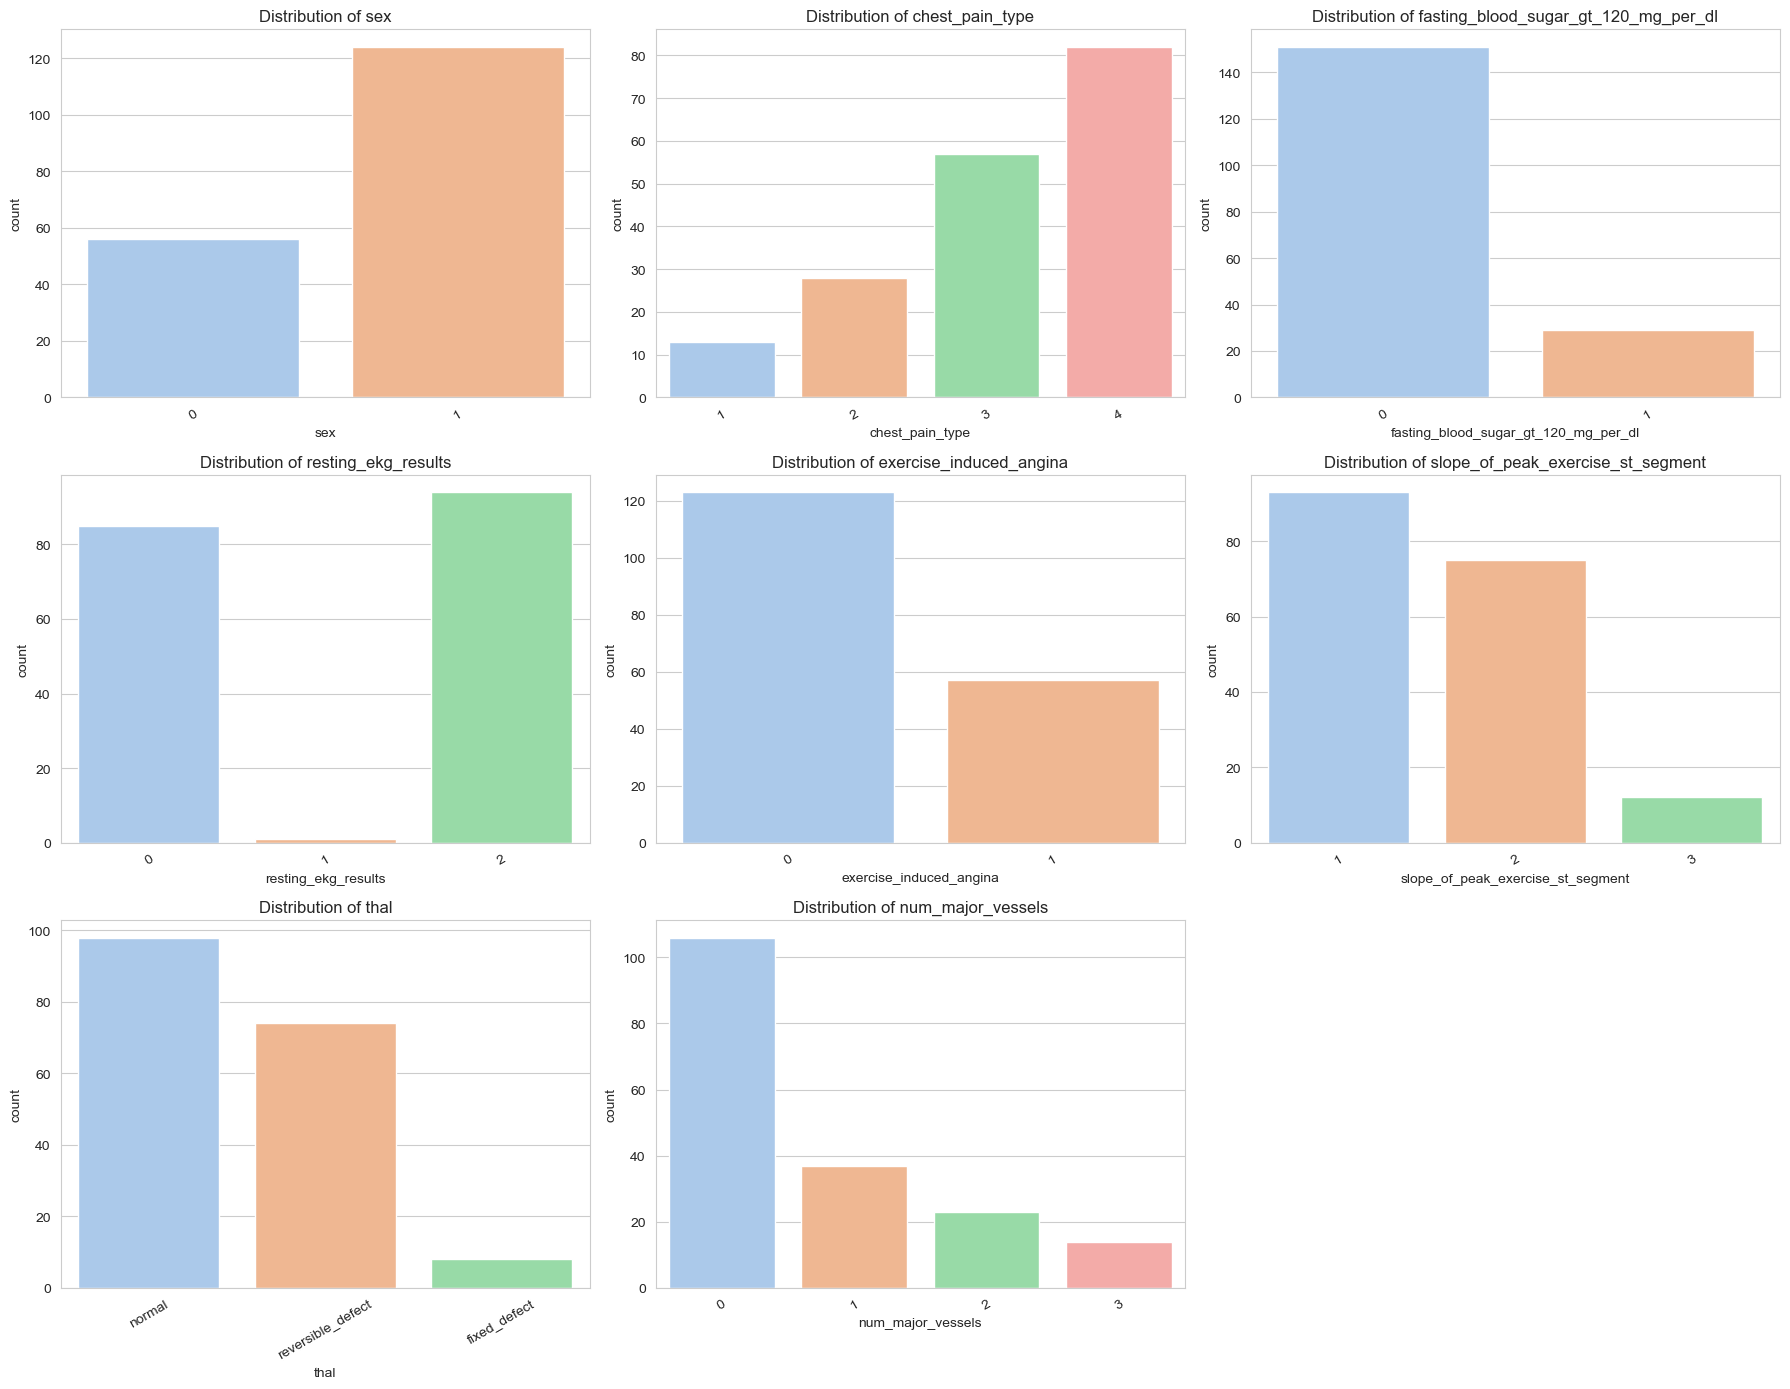

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, hue=col, ax=axes[i], palette='pastel', legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(categorical_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

### Numerical Features vs. Target Variable

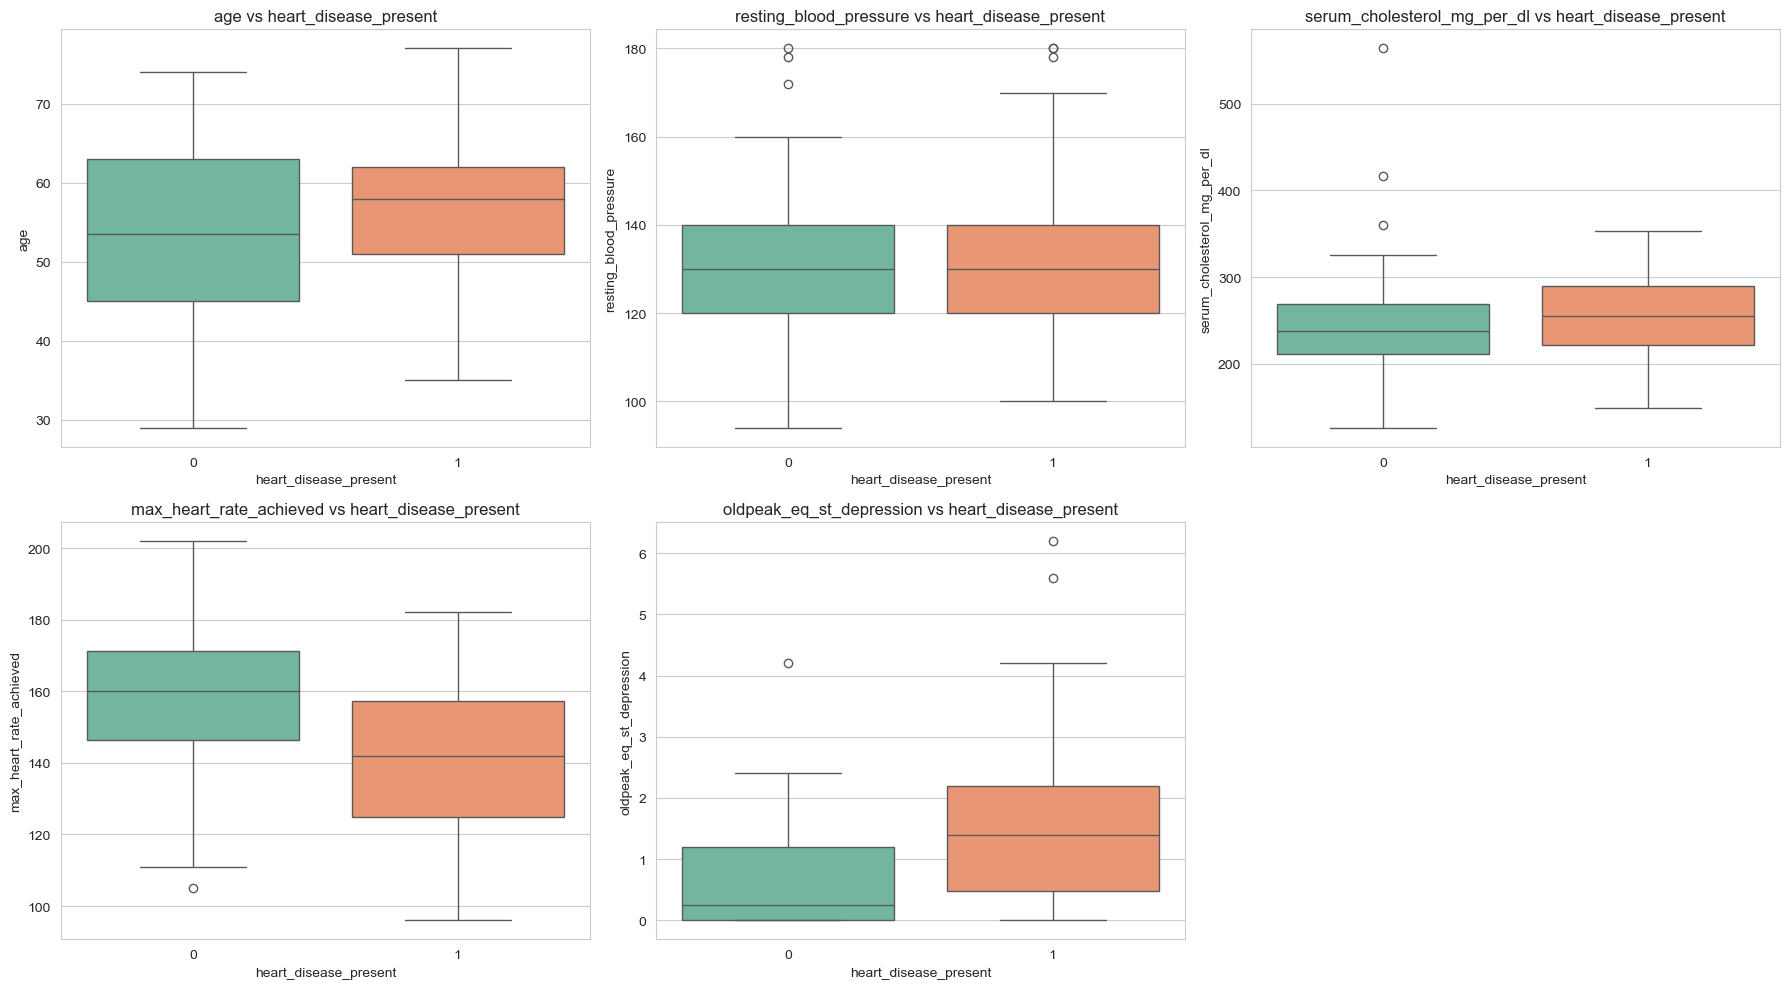

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=target_col, y=col, data=df, hue=target_col, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'{col} vs {target_col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

### Categorical Features vs. Target Variable

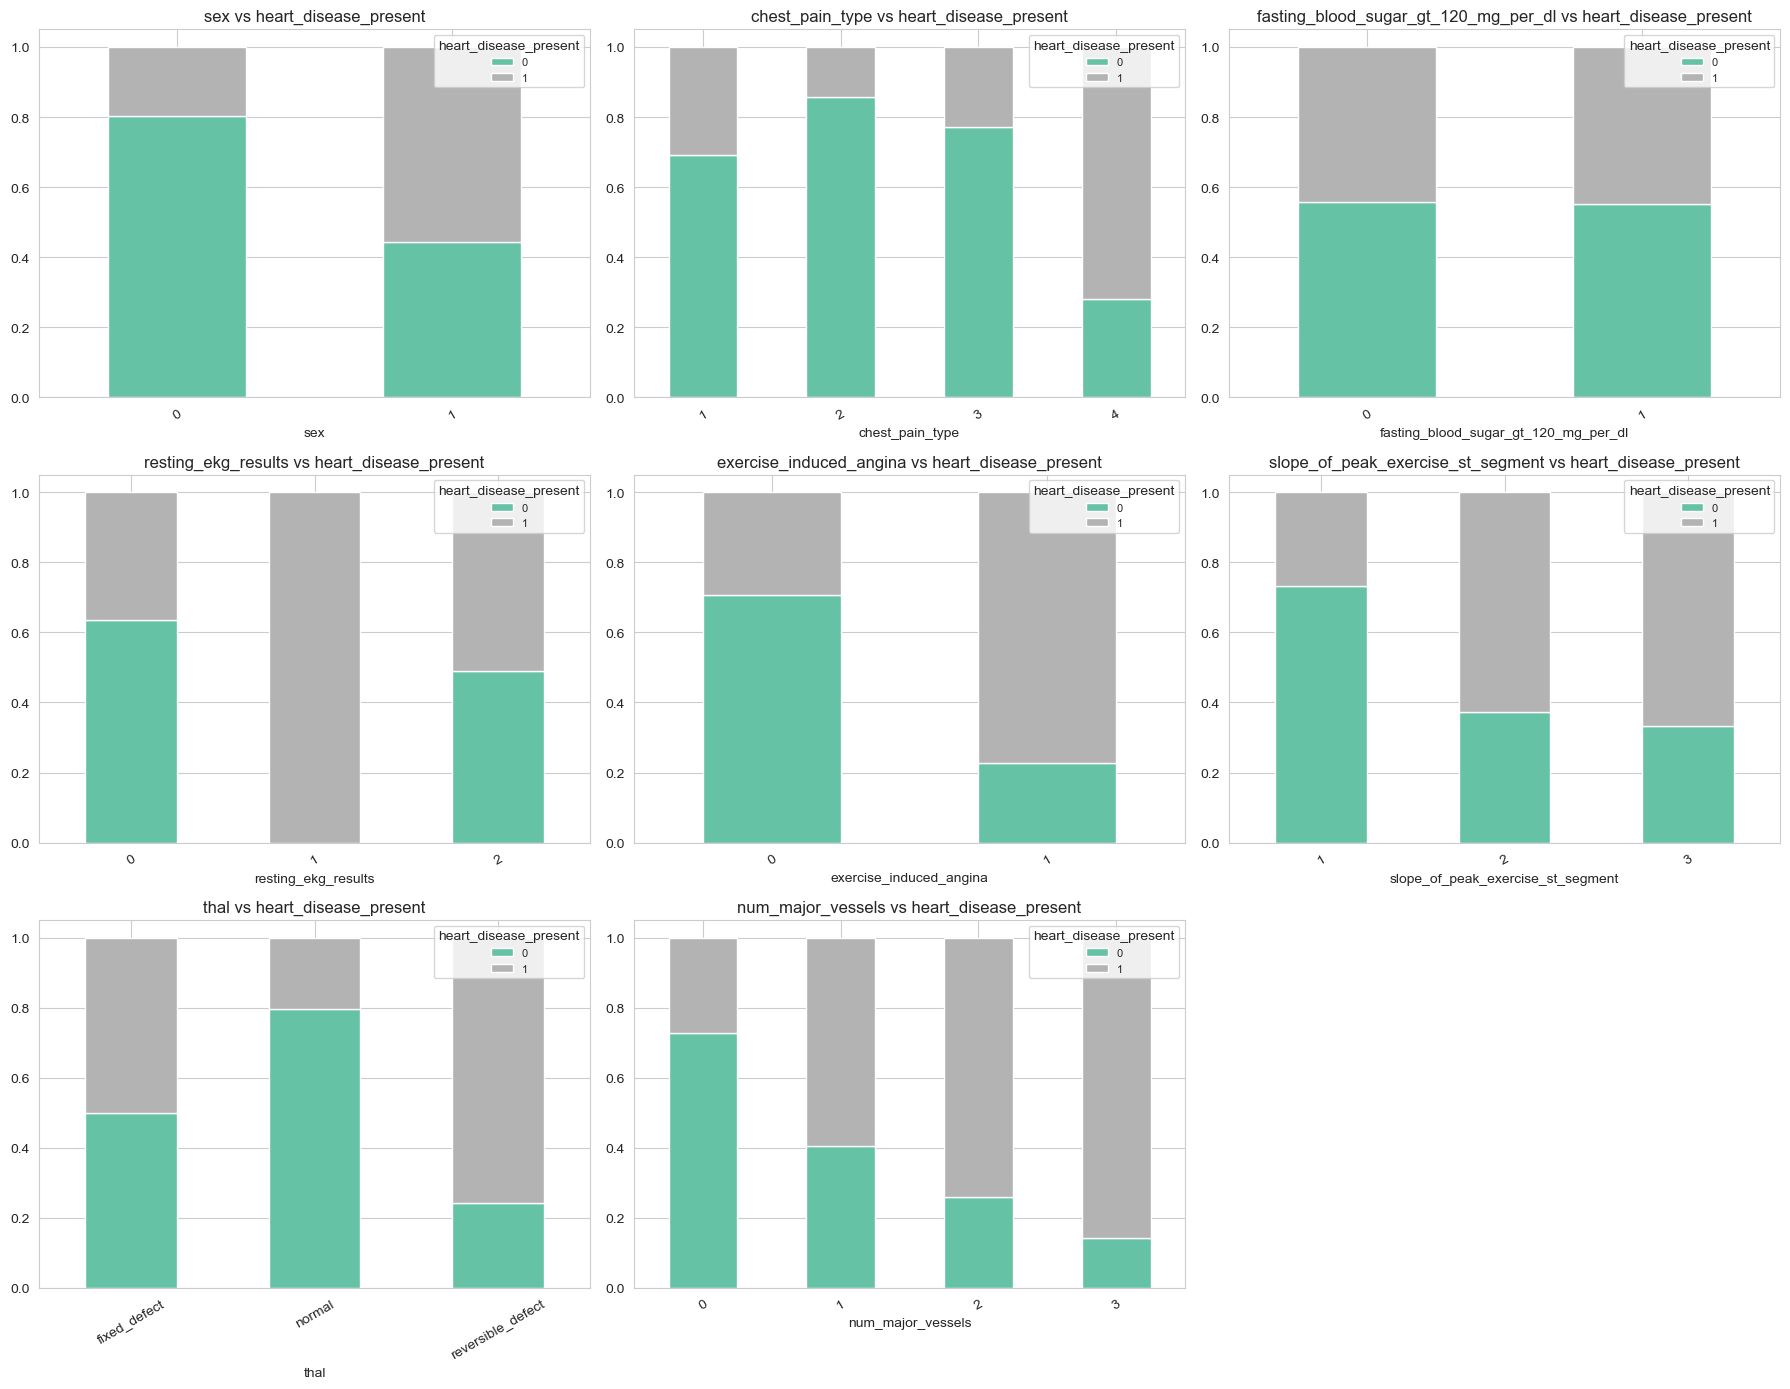

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df[target_col], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2')
    axes[i].set_title(f'{col} vs {target_col}')
    axes[i].legend(title=target_col, fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(categorical_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

###  Numerical Feature Correlation Matrix & Heatmap

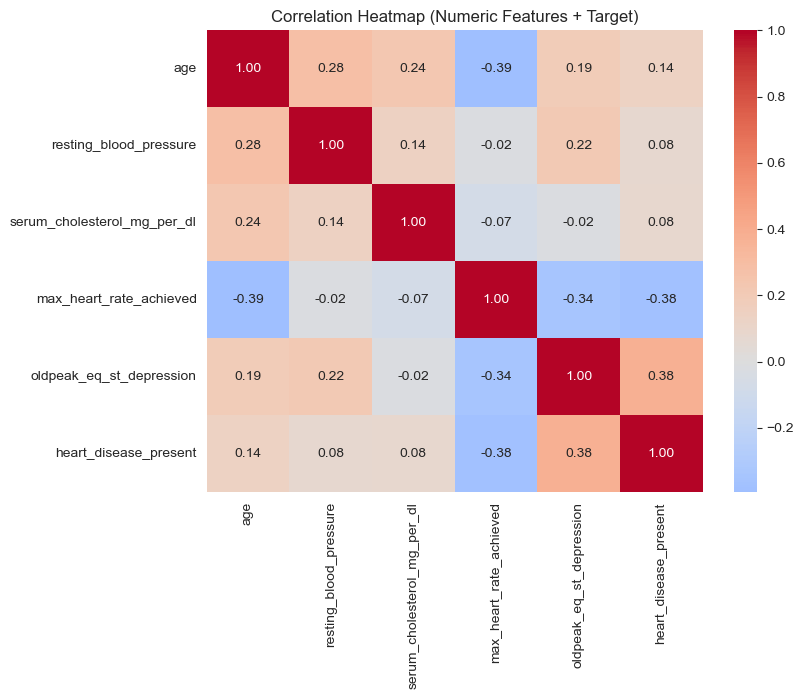

In [13]:
corr = df[numeric_cols + [target_col]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features + Target)')
plt.show()

### Full Feature Correlation Heatmap

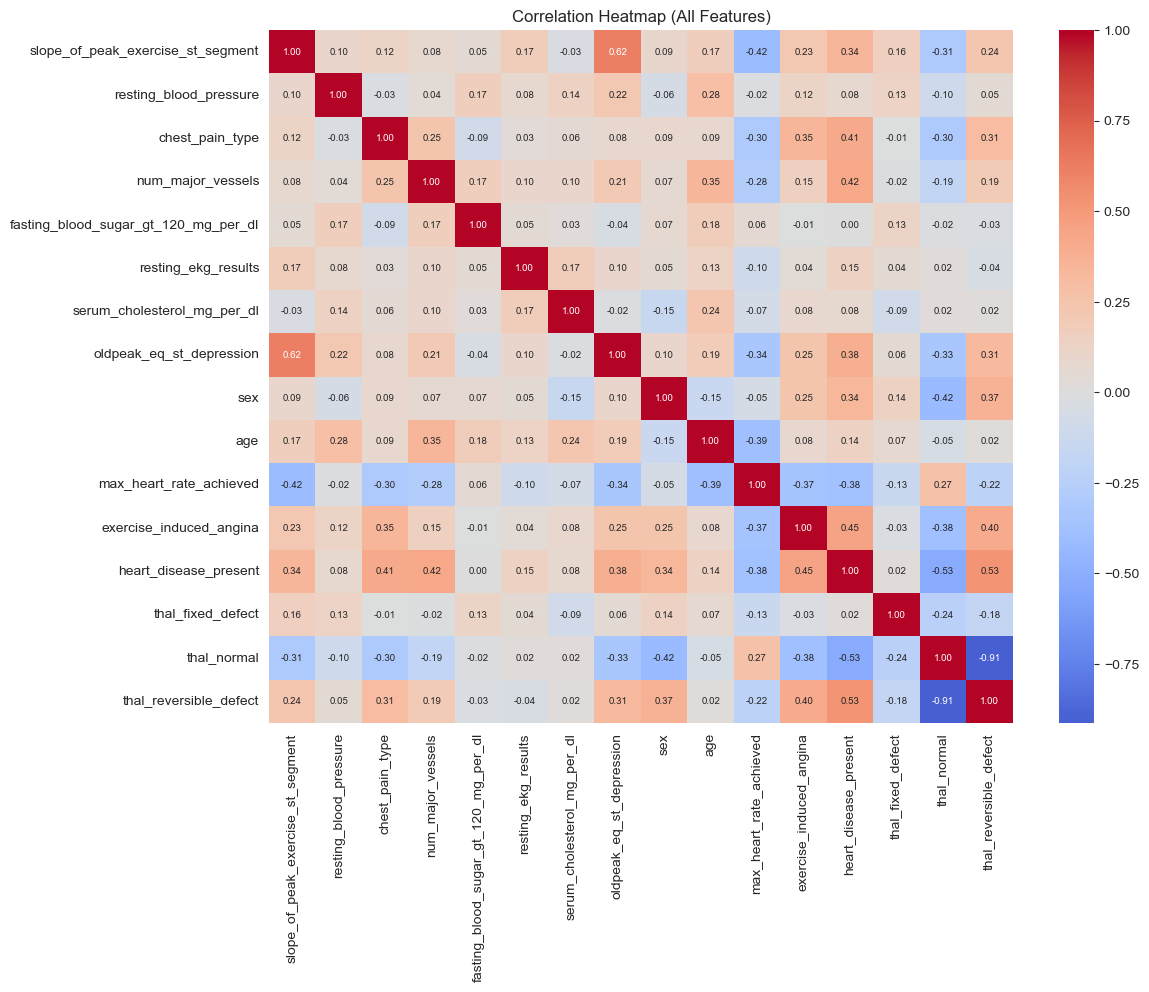

Top correlations with target:
heart_disease_present                   1.000000
thal_reversible_defect                  0.525145
exercise_induced_angina                 0.448647
num_major_vessels                       0.421519
chest_pain_type                         0.412829
oldpeak_eq_st_depression                0.382930
slope_of_peak_exercise_st_segment       0.344224
sex                                     0.335421
resting_ekg_results                     0.145933
age                                     0.138255
serum_cholesterol_mg_per_dl             0.079775
resting_blood_pressure                  0.078506
thal_fixed_defect                       0.024112
fasting_blood_sugar_gt_120_mg_per_dl    0.003379
max_heart_rate_achieved                -0.375352
thal_normal                            -0.528812
Name: heart_disease_present, dtype: float64


In [14]:
df_corr = df.drop(columns=['patient_id']).copy()
df_corr = pd.get_dummies(df_corr, columns=['thal'], drop_first=False)
full_corr = df_corr.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={"size":7})
plt.title('Correlation Heatmap (All Features)')
plt.show()

print("Top correlations with target:")
print(full_corr[target_col].sort_values(ascending=False))

### Pairwise Numerical Relationships & Kernel Density Plots

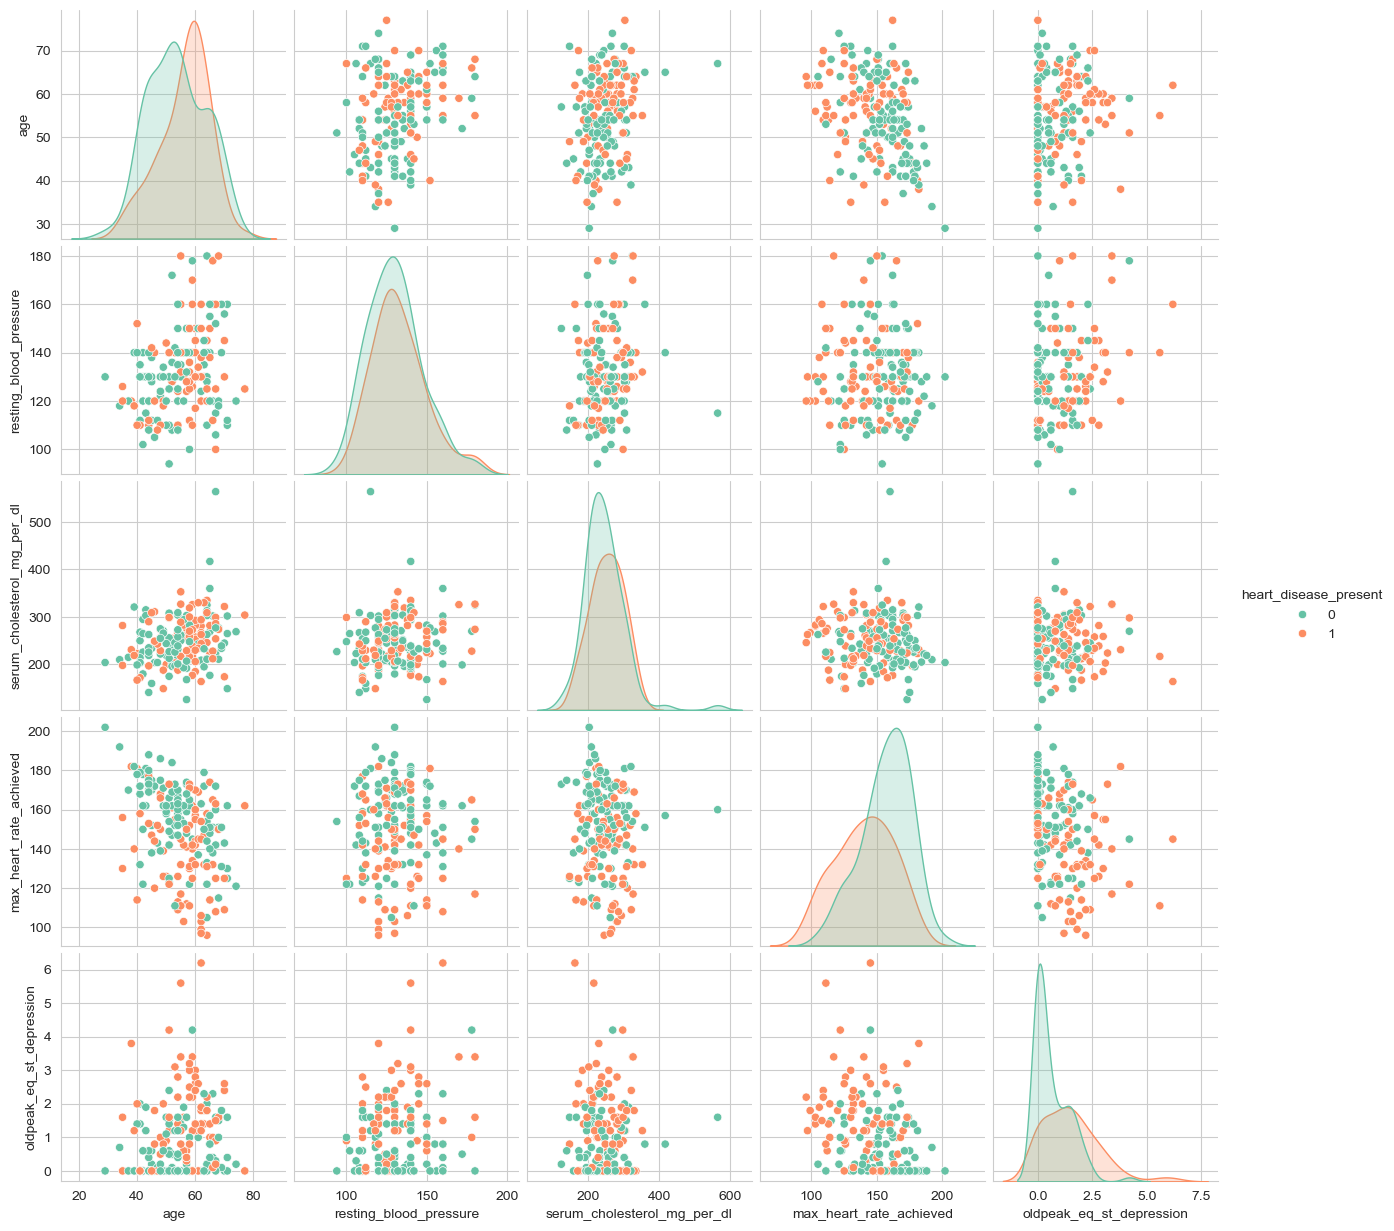

In [15]:
sns.pairplot(df[numeric_cols + [target_col]], hue=target_col, palette='Set2', diag_kind='kde')
plt.show()

### Statistical Hypothesis Testing

In [16]:
print("--- T-test (numeric features) ---")
for col in numeric_cols:
    grp0 = df[df[target_col]==0][col]
    grp1 = df[df[target_col]==1][col]
    t, p = stats.ttest_ind(grp0, grp1, equal_var=False)
    sig = "significant" if p < 0.05 else "not significant"
    print(f"{col}: p={p:.4f} ({sig})")

print("\n--- Chi-square test (categorical features) ---")
for col in categorical_cols:
    ct = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    sig = "significant" if p < 0.05 else "not significant"
    print(f"{col}: p={p:.4f} ({sig})")

--- T-test (numeric features) ---
age: p=0.0606 (not significant)
resting_blood_pressure: p=0.2947 (not significant)
serum_cholesterol_mg_per_dl: p=0.2766 (not significant)
max_heart_rate_achieved: p=0.0000 (significant)
oldpeak_eq_st_depression: p=0.0000 (significant)

--- Chi-square test (categorical features) ---
sex: p=0.0000 (significant)
chest_pain_type: p=0.0000 (significant)
fasting_blood_sugar_gt_120_mg_per_dl: p=1.0000 (not significant)
resting_ekg_results: p=0.0778 (not significant)
exercise_induced_angina: p=0.0000 (significant)
slope_of_peak_exercise_st_segment: p=0.0000 (significant)
thal: p=0.0000 (significant)
num_major_vessels: p=0.0000 (significant)


### Feature Encoding & Target Splitting

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df_model = df.drop(columns=['patient_id']).copy()
df_model = pd.get_dummies(df_model, columns=['thal'], drop_first=True)
X = df_model.drop(columns=['heart_disease_present'])
y = df_model['heart_disease_present']
print(X.shape, y.shape)
X.head()

(180, 14) (180,)


,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_normal,thal_reversible_defect
0,1,128,2,0,0,2,308,0.0,1,45,170,0,True,False
1,2,110,3,0,0,0,214,1.6,0,54,158,0,True,False
2,1,125,4,3,0,2,304,0.0,1,77,162,1,True,False
3,1,152,4,0,0,0,223,0.0,1,40,181,0,False,True
4,3,178,1,0,0,2,270,4.2,1,59,145,0,False,True


### Train-Test Data Splitting

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (144, 14) Test: (36, 14)


### Feature Scaling

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled shapes:", X_train_scaled.shape, X_test_scaled.shape)

Scaled shapes: (144, 14) (36, 14)


### Model Training & Evaluation

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(random_state=42, probability=True)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.861111,0.789474,0.9375,0.857143
1,SVM,0.861111,0.823529,0.8750,0.848485
2,Logistic Regression,0.833333,0.777778,0.8750,0.823529
3,KNN,0.833333,0.777778,0.8750,0.823529
4,Decision Tree,0.777778,0.750000,0.7500,0.750000


### Comparative Performance Visualization

C:\Users\srinithi\AppData\Local\Temp\ipykernel_3756\3902613998.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, ax=axes[1], palette='viridis')


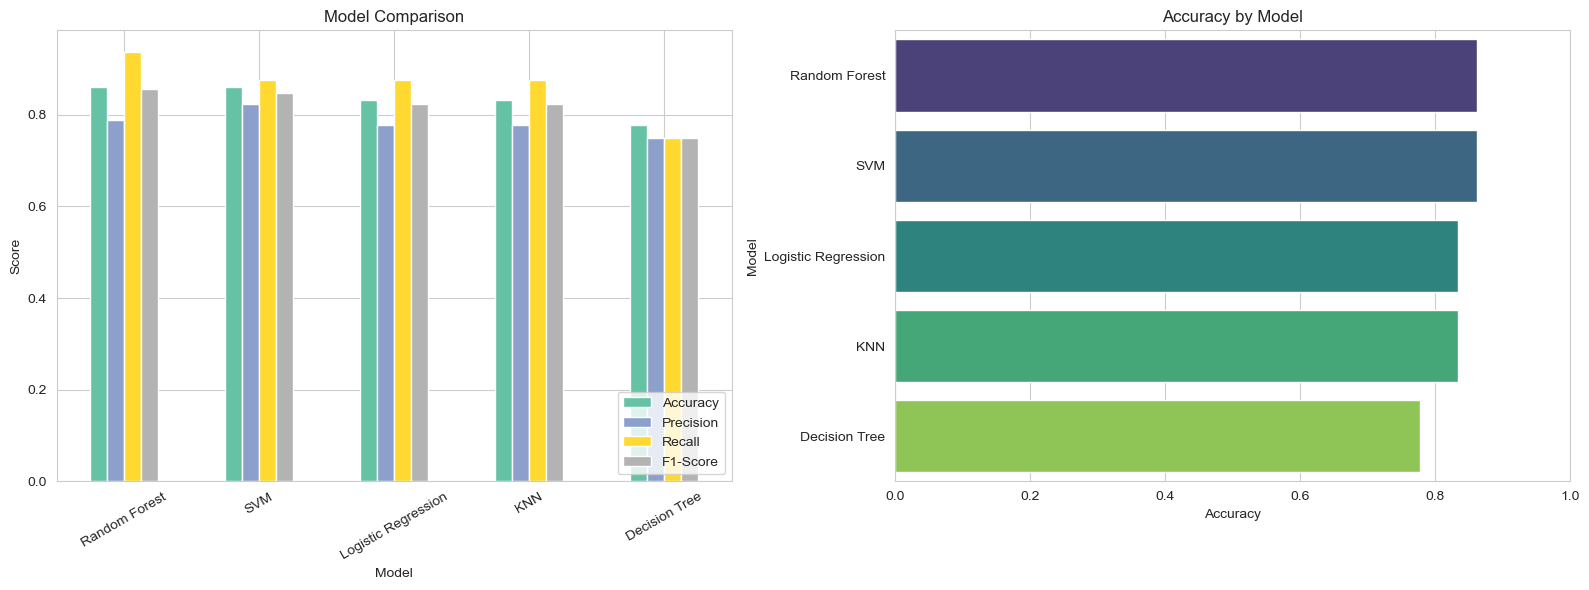

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[0], colormap='Set2'
)
axes[0].set_title('Model Comparison')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x='Accuracy', y='Model', data=results_df, ax=axes[1], palette='viridis')
axes[1].set_title('Accuracy by Model')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Best Model Selection & Confusion Matrix

Best model: Random Forest
Confusion Matrix:
[[16  4]
 [ 1 15]]


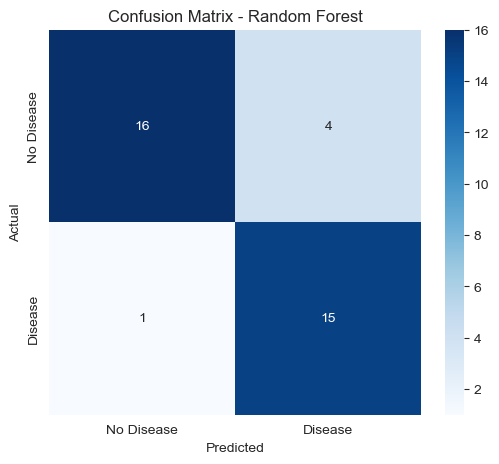

In [22]:
from sklearn.metrics import confusion_matrix

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
print(f"Best model: {best_model_name}")
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Random Forest Feature Importance Analysis

C:\Users\srinithi\AppData\Local\Temp\ipykernel_3756\3693078175.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako')


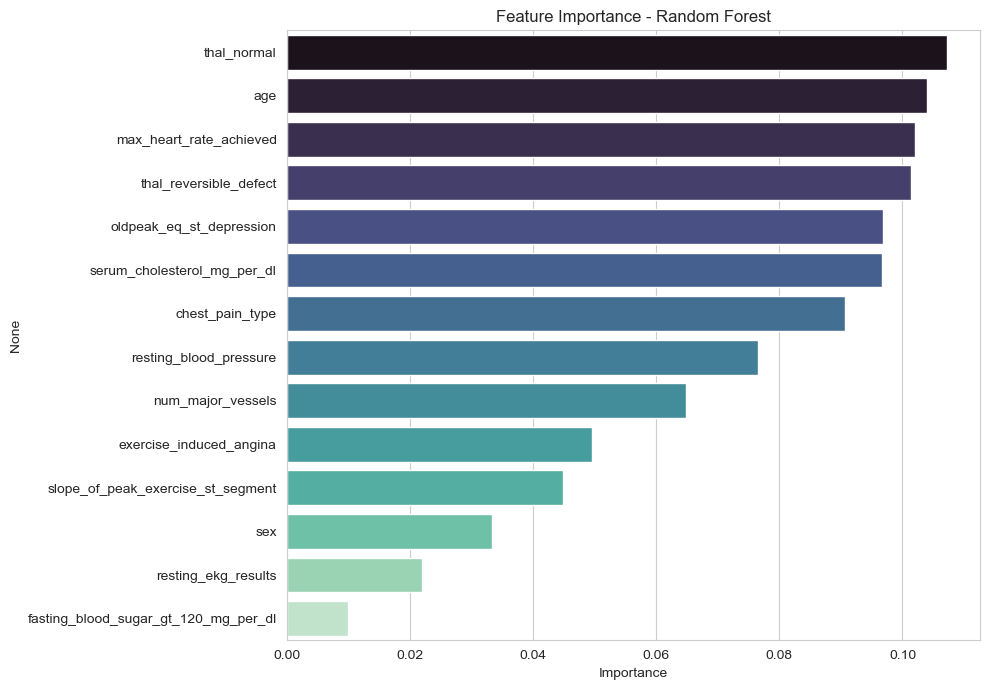

thal_normal                             0.107230
age                                     0.104026
max_heart_rate_achieved                 0.101994
thal_reversible_defect                  0.101338
oldpeak_eq_st_depression                0.096840
serum_cholesterol_mg_per_dl             0.096613
chest_pain_type                         0.090714
resting_blood_pressure                  0.076526
num_major_vessels                       0.064919
exercise_induced_angina                 0.049577
slope_of_peak_exercise_st_segment       0.044857
sex                                     0.033332
resting_ekg_results                     0.022021
fasting_blood_sugar_gt_120_mg_per_dl    0.010013
dtype: float64


In [23]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances)

### Actual vs. Predicted Comparison Table

In [24]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best
})
comparison['Correct'] = comparison['Actual'] == comparison['Predicted']
comparison.head(10)

,Actual,Predicted,Correct
0,0,0,True
1,1,1,True
2,1,1,True
3,0,0,True
4,0,0,True
5,1,0,False
6,0,1,False
7,0,0,True
8,0,1,False
9,1,1,True


### Inference Function Definition

In [25]:
def predict_heart_disease(slope, resting_bp, chest_pain, num_vessels, fasting_sugar,
                            resting_ekg, cholesterol, oldpeak, sex, age,
                            max_heart_rate, exercise_angina, thal):
    """
    thal must be one of: 'normal', 'fixed_defect', 'reversible_defect'
    sex: 1 = male, 0 = female
    fasting_sugar, exercise_angina: 1 = True/Yes, 0 = False/No
    """
    thal_normal = 1 if thal == 'normal' else 0
    thal_reversible = 1 if thal == 'reversible_defect' else 0

    patient = pd.DataFrame({
        'slope_of_peak_exercise_st_segment': [slope],
        'resting_blood_pressure': [resting_bp],
        'chest_pain_type': [chest_pain],
        'num_major_vessels': [num_vessels],
        'fasting_blood_sugar_gt_120_mg_per_dl': [fasting_sugar],
        'resting_ekg_results': [resting_ekg],
        'serum_cholesterol_mg_per_dl': [cholesterol],
        'oldpeak_eq_st_depression': [oldpeak],
        'sex': [sex],
        'age': [age],
        'max_heart_rate_achieved': [max_heart_rate],
        'exercise_induced_angina': [exercise_angina],
        'thal_normal': [thal_normal],
        'thal_reversible_defect': [thal_reversible]
    })

    patient_scaled = scaler.transform(patient)
    pred = best_model.predict(patient_scaled)[0]
    prob = best_model.predict_proba(patient_scaled)[0][1]

    print(f"Prediction: {'Heart Disease Present' if pred == 1 else 'No Heart Disease'}")
    print(f"Probability of heart disease: {prob*100:.1f}%")
    return pred, prob

### Low-Risk Patient Test Case

In [26]:
predict_heart_disease(
    slope=1, resting_bp=125, chest_pain=2, num_vessels=0,
    fasting_sugar=0, resting_ekg=0, cholesterol=210,
    oldpeak=0.5, sex=0, age=40, max_heart_rate=170,
    exercise_angina=0, thal='normal'
)

Prediction: No Heart Disease
Probability of heart disease: 2.0%


(np.int64(0), np.float64(0.02))

### High-Risk Patient Test Case

In [29]:
predict_heart_disease(
    slope=2, resting_bp=150, chest_pain=4, num_vessels=2,
    fasting_sugar=0, resting_ekg=2, cholesterol=280,
    oldpeak=2.5, sex=1, age=62, max_heart_rate=120,
    exercise_angina=1, thal='reversible_defect'
)

Prediction: Heart Disease Present
Probability of heart disease: 100.0%


(np.int64(1), np.float64(1.0))

## Hospital Recommendations & Conclusion

### Suggestions to the Hospital
* **Early-Warning Screening:** Deploy the real-time inference model (`predict_heart_disease`) in outpatient registration systems to automatically flag high-risk cardiac patients during initial check-ups.
* **Priority Diagnostic Testing:** Focus hospital testing resources on high-impact parameters like Thallium stress testing (`thal`) and exercise ST depression (`oldpeak_eq_st_depression`) to optimize diagnostic workflows.
* **Resource Management:** Allocate ICU beds, cardiac care units (CCU), emergency resuscitation kits, and specialized cardiologists based on predicted risk trends.
* **Risk Stratification:** Establish automated clinical alerts for patients presenting with combination risk factors (e.g., male sex, ST depression > 2.0, exercise-induced angina).
* **Preventive Health Programs:** Conduct targeted preventive cardiology workshops and routine health screenings for individuals displaying borderline risk scores.

### Conclusion
* The clinical heart disease dataset was successfully preprocessed, cleaned, and analyzed to identify key risk factors.
* Statistical hypothesis testing confirmed significant dependencies between heart disease and parameters such as `thal`, `max_heart_rate_achieved`, and `oldpeak_eq_st_depression`.
* Five machine learning algorithms (Logistic Regression, Decision Tree, Random Forest, KNN, and SVM) were evaluated on the dataset.
* **Random Forest** achieved the best overall performance with **86.1% Accuracy** and a high **93.8% Recall**, making it the primary model for clinical screening.
* A real-time single-patient inference pipeline was built and validated on low-risk (2.0% probability) and high-risk (100.0% probability) clinical profiles.
* These predictions provide actionable insights to hospital management for early detection, triage, and cardiac care planning.

## Future Scope

* **Pipeline Deployment:** Package the prediction model into a web application using Streamlit or Flask for easy clinical use.
* **Database Integration:** Connect the inference model directly to Electronic Health Record (EHR) systems for automated risk scoring.
* **Dataset Expansion:** Collect larger and more diverse patient demographics to further improve model generalizability.
* **Advanced Architecture:** Explore deep learning models (ANNs) and advanced boosting algorithms (XGBoost, LightGBM) to push predictive accuracy higher.
* **Feature Integration:** Incorporate external lifestyle metrics like daily activity levels, dietary habits, and genetic markers for a more holistic cardiac evaluation.